# 20｜視覺與多模態Transformer

把影像切成 patches，再以正規化向量比較圖文相似度。

對應 `slides/20_視覺與多模態Transformer.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/16_vision_and_multimodal_transformers.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 ViT From Scratch、CLIP 區段。

- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
image = np.arange(16).reshape(4,4)
patches = np.stack([image[i:i+2,j:j+2].ravel() for i in (0,2) for j in (0,2)])
image_emb = np.array([[.9,.1], [.2,.8]])
text_emb = np.array([[1.,0.], [0.,1.], [.7,.7]])
labels = ['貓', '街景', '戶外動物']
norm = lambda x: x / np.linalg.norm(x, axis=1, keepdims=True)
sim = norm(image_emb) @ norm(text_emb).T
print('patch matrix:\n', patches)
pd.DataFrame(sim, index=['image_A','image_B'], columns=labels).round(3)

patch matrix:
 [[ 0  1  4  5]
 [ 2  3  6  7]
 [ 8  9 12 13]
 [10 11 14 15]]


,貓,街景,戶外動物
image_A,0.994,0.11,0.781
image_B,0.243,0.97,0.857


## 執行結果圖

/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 35987 (\N{CJK UNIFIED IDEOGRAPH-8C93}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 34903 (\N{CJK UNIFIED IDEOGRAPH-8857}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 25142 (\N{CJK UNIFIED IDEOGRAPH-6236}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Use

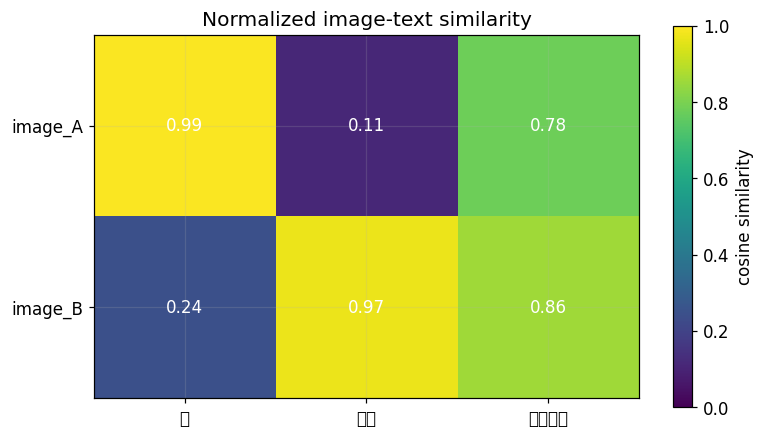

In [3]:
plt.imshow(sim, cmap='viridis', vmin=0, vmax=1)
plt.xticks(range(3), labels); plt.yticks(range(2), ['image_A','image_B'])
plt.colorbar(label='cosine similarity'); plt.title('Normalized image-text similarity')
for (i,j), value in np.ndenumerate(sim): plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='white')
savefig('20_multimodal_demo')
report('multimodal', {'patches': patches.tolist(), 'similarity': sim.tolist()})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。